<a href="https://colab.research.google.com/github/Laxmi-muniya/Laxmi/blob/main/RL1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

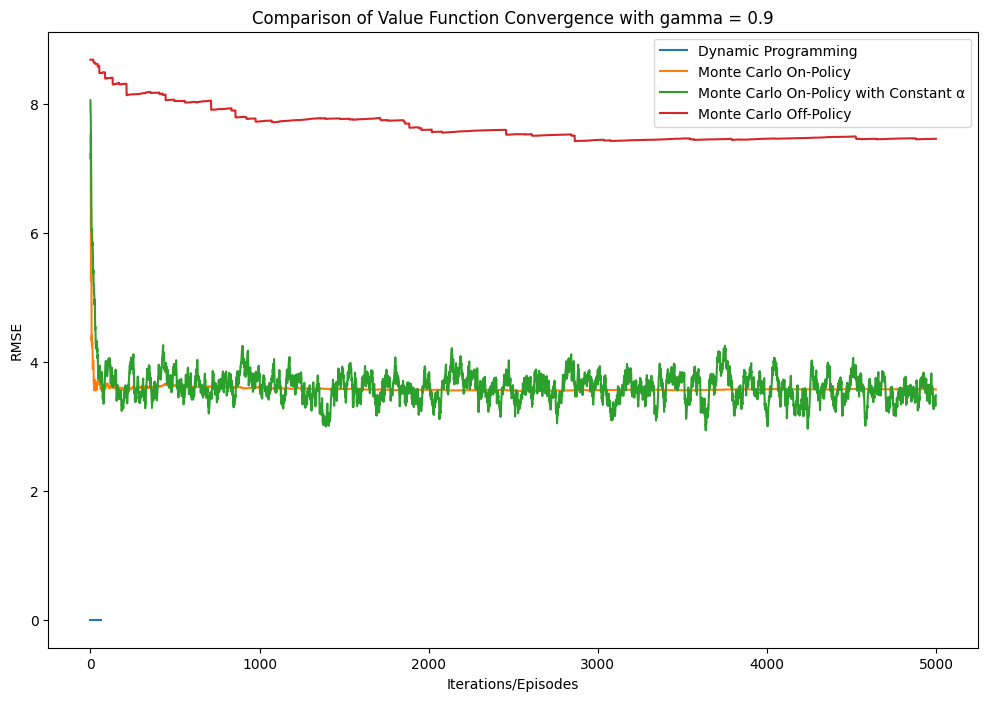

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict

# Define the grid environment
m, n = 5, 5
S = [(r, c) for r in range(m) for c in range(n)]  # State space
A = ['north', 'south', 'east', 'west']  # Actions
terminal = [(4, 4)]  # Terminal state
gamma = 0.9  # Updated Discount factor
alpha = 0.1  # Constant learning rate for On-Policy Monte Carlo with Constant α

# Transition function
def transition(s, a, s_next):
    r, c = s
    if a == 'north':
        r = r if r == 0 else r - 1
    if a == 'south':
        r = r if r == 4 else r + 1
    if a == 'east':
        c = c if c == 4 else c + 1
    if a == 'west':
        c = c if c == 0 else c - 1
    prob = 1 if (r, c) == s_next else 0
    reward = 0 if s_next in terminal else -1
    return prob, reward

# Convert value function dictionary to NumPy array for easy display
def to_numpy(v, m, n):
    vnum = np.zeros((m, n))
    for s in v:
        vnum[s] = v[s]
    return vnum

# Compute RMSE between two value functions
def compute_rmse(v, v_true):
    error = 0
    for s in v:
        error += (v[s] - v_true[s]) ** 2
    return np.sqrt(error / len(v))

#############################
# 1. Dynamic Programming (Synchronous)
#############################
v_dp = {s: 0 for s in S}  # Initialize value function
theta = 1e-3  # Convergence threshold
delta = theta + 1
iter_dp = 0
rmse_dp = []  # Track RMSE over iterations
pi = {s: np.ones(len(A)) / len(A) for s in S}  # Uniform random policy

while delta >= theta:
    iter_dp += 1
    v_next = {s: 0 for s in S}
    delta = 0

    for s in S:
        if s in terminal:
            continue

        for a in A:
            total_value = 0
            for s_next in S:
                prob, reward = transition(s, a, s_next)
                total_value += prob * (reward + gamma * v_dp[s_next])
            v_next[s] += pi[s][A.index(a)] * total_value

        delta = max(delta, abs(v_next[s] - v_dp[s]))

    v_dp = v_next.copy()  # Update the value function
    rmse_dp.append(compute_rmse(v_dp, v_dp))  # Compare to itself for now

# Save final DP value function as the true reference
v_true = v_dp.copy()

#############################
# 2. Monte Carlo On-Policy
#############################
num_episodes = 5000
max_steps_per_episode = 100
v_on_policy = {s: 0 for s in S}  # Initialize value function
returns_sum = defaultdict(float)  # Sum of returns for each state
returns_count = defaultdict(float)  # Count of returns for each state
rmse_on_policy = []

# Define policy
policy = {s: np.ones(len(A)) / len(A) for s in S}

for episode in range(num_episodes):
    episode_data = []
    s = random.choice(S)
    while s not in terminal:
        a = random.choices(A, weights=[policy[s][A.index(a)] for a in A])[0]
        s_next = random.choice(S)
        prob, reward = transition(s, a, s_next)
        episode_data.append((s, a, reward))
        s = s_next

    G = 0
    visited_states = set()

    for t in range(len(episode_data) - 1, -1, -1):
        s, a, reward = episode_data[t]
        G = reward + gamma * G
        if s not in visited_states:
            returns_sum[s] += G
            returns_count[s] += 1
            v_on_policy[s] = returns_sum[s] / returns_count[s]
            visited_states.add(s)

    # Track RMSE against DP solution
    rmse_on_policy.append(compute_rmse(v_on_policy, v_true))

#############################
# 3. Monte Carlo On-Policy with Constant α
#############################
v_on_policy_alpha = {s: 0 for s in S}  # Initialize value function with α
rmse_on_policy_alpha = []

for episode in range(num_episodes):
    episode_data = []
    s = random.choice(S)
    while s not in terminal:
        a = random.choices(A, weights=[policy[s][A.index(a)] for a in A])[0]
        s_next = random.choice(S)
        prob, reward = transition(s, a, s_next)
        episode_data.append((s, a, reward))
        s = s_next

    G = 0
    visited_states = set()

    for t in range(len(episode_data) - 1, -1, -1):
        s, a, reward = episode_data[t]
        G = reward + gamma * G
        if s not in visited_states:
            # Use the constant α for the update
            v_on_policy_alpha[s] = v_on_policy_alpha[s] + alpha * (G - v_on_policy_alpha[s])
            visited_states.add(s)

    # Track RMSE against DP solution
    rmse_on_policy_alpha.append(compute_rmse(v_on_policy_alpha, v_true))

#############################
# 4. Monte Carlo Off-Policy
#############################
v_off_policy = {s: 0 for s in S}  # Initialize value function
cumulative_weights = defaultdict(float)  # Cumulative weights
rmse_off_policy = []
behavior_policy = {s: {a: 1/len(A) for a in A} for s in S}  # Random behavior policy
target_policy = {s: {a: 0 for a in A} for s in S}  # Always move east
for s in S:
    if 'east' in A:
        target_policy[s]['east'] = 1

for episode in range(num_episodes):
    episode_data = []
    s = random.choice(S)
    while s not in terminal:
        a = random.choices(A, weights=[behavior_policy[s][a] for a in A])[0]
        s_next = random.choice(S)
        prob, reward = transition(s, a, s_next)
        episode_data.append((s, a, reward))
        s = s_next

    G = 0
    importance_sampling_ratio = 1.0

    for t in range(len(episode_data) - 1, -1, -1):
        s, a, reward = episode_data[t]
        G = reward + gamma * G
        if target_policy[s][a] == 0:
            break
        importance_sampling_ratio *= target_policy[s][a] / behavior_policy[s][a]
        cumulative_weights[s] += importance_sampling_ratio
        v_off_policy[s] += (importance_sampling_ratio / cumulative_weights[s]) * (G - v_off_policy[s])

    # Track RMSE against DP solution
    rmse_off_policy.append(compute_rmse(v_off_policy, v_true))

#############################
# Plot Comparison of RMSE
#############################
plt.figure(figsize=(12, 8))
plt.plot(rmse_dp, label="Dynamic Programming")
plt.plot(rmse_on_policy, label="Monte Carlo On-Policy")
plt.plot(rmse_on_policy_alpha, label="Monte Carlo On-Policy with Constant α")
plt.plot(rmse_off_policy, label="Monte Carlo Off-Policy")
plt.xlabel('Iterations/Episodes')
plt.ylabel('RMSE')
plt.title('Comparison of Value Function Convergence with gamma = 0.9')
plt.legend()
plt.show()


Dynamic Programming (DP): The blue line at the bottom of the graph shows that Dynamic Programming converges almost instantly, achieving a value close to zero RMSE. This method is deterministic and typically the most efficient if the transition dynamics are known, as it doesn't rely on episodes but rather computes the value function directly.

Monte Carlo On-Policy: The yellow line follows closely behind Dynamic Programming. It starts with a slightly higher RMSE but stabilizes quickly and remains consistent over time, showing good performance.

Monte Carlo On-Policy with Constant α: The green line fluctuates more than the simple Monte Carlo On-Policy. Although it does reduce the error quickly in the early stages, it shows high variance throughout the iterations. The introduction of a constant learning rate (α) likely contributes to these fluctuations, as it's not adaptive to the data.

Monte Carlo Off-Policy: The red line shows the poorest performance. Its RMSE starts high and decreases very slowly. The off-policy method likely struggles due to the need for importance sampling, which can introduce variance and instability, especially if the behavior policy and target policy differ significantly.

Conclusion:
Dynamic Programming is clearly the best, with fast convergence and minimal RMSE.
Monte Carlo On-Policy performs well with relatively stable convergence.
Monte Carlo On-Policy with Constant α has more fluctuations, showing that while it can learn, the constant α causes some instability.
Monte Carlo Off-Policy is the least efficient, with slow convergence and consistently higher RMSE.